<a href="https://colab.research.google.com/github/arumugapandi76/python-learning/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tokenization and Embedding

In [ ]:

from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

text = "I took my money to the bank."

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text)

print("Tokens:", tokens)
print("Token IDs:", token_ids)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Tokens: ['I', 'Ġtook', 'Ġmy', 'Ġmoney', 'Ġto', 'Ġthe', 'Ġbank', '.']
Token IDs: [40, 1718, 616, 1637, 284, 262, 3331, 13]


Transformer Attention

In [ ]:
from transformers import GPT2Tokenizer, GPT2Model
import torch

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2", output_attentions=True) # Add output_attentions=True

text = "I took my money to the bank."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

print("Token Embeddings Shape:", outputs.last_hidden_state.shape)  # (1, seq_len, hidden_size)

# Get the attention weights from the first layer (for simplicity)
# outputs.attentions is a tuple, each element is the attention weights for a layer
# The shape of attention weights for one layer: (batch_size, num_heads, seq_len, seq_len)
attention_weights = outputs.attentions[0]

# We'll take the mean across all attention heads and the batch size
mean_attention_weights = attention_weights.mean(dim=1).squeeze(0) # Shape: (seq_len, seq_len)

print("Mean Attention Weights Shape:", mean_attention_weights.shape)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Token Embeddings Shape: torch.Size([1, 8, 768])
Mean Attention Weights Shape: torch.Size([8, 8])


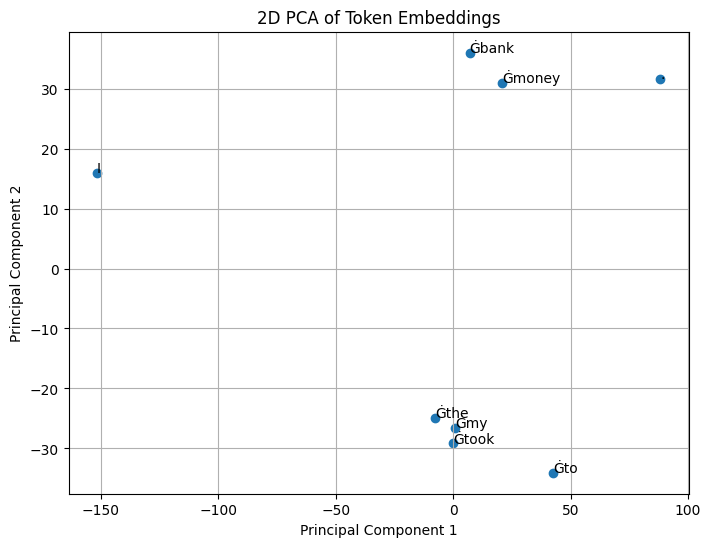

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get the token embeddings
token_embeddings = outputs.last_hidden_state.squeeze(0).detach().numpy()

# Apply PCA to reduce dimensionality to 2
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(token_embeddings)

# Get the actual tokens
tokens = tokenizer.tokenize(text)

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])

# Add annotations for each token
for i, token in enumerate(tokens):
    plt.annotate(token, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))

plt.title("2D PCA of Token Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Sel attention

In [ ]:
import torch
import torch.nn.functional as F

# Simulated embeddings for 6 tokens
x = torch.randn(6, 4)  # 6 tokens, 4 features each

W_q = torch.randn(4, 2)
W_k = torch.randn(4, 2)
W_v = torch.randn(4, 2)

Q = x @ W_q
K = x @ W_k
V = x @ W_v

scores = Q @ K.T
scaled = scores / torch.sqrt(torch.tensor(K.shape[1], dtype=torch.float32))
weights = F.softmax(scaled, dim=-1)
output = weights @ V

print("Self-Attention Output:\n", output)

Self-Attention Output:
 tensor([[-4.8748, -3.8290],
        [-4.9920, -3.8966],
        [ 2.9739,  2.2758],
        [ 4.6703,  3.5180],
        [ 3.5611,  2.7729],
        [-4.7208, -3.7332]])


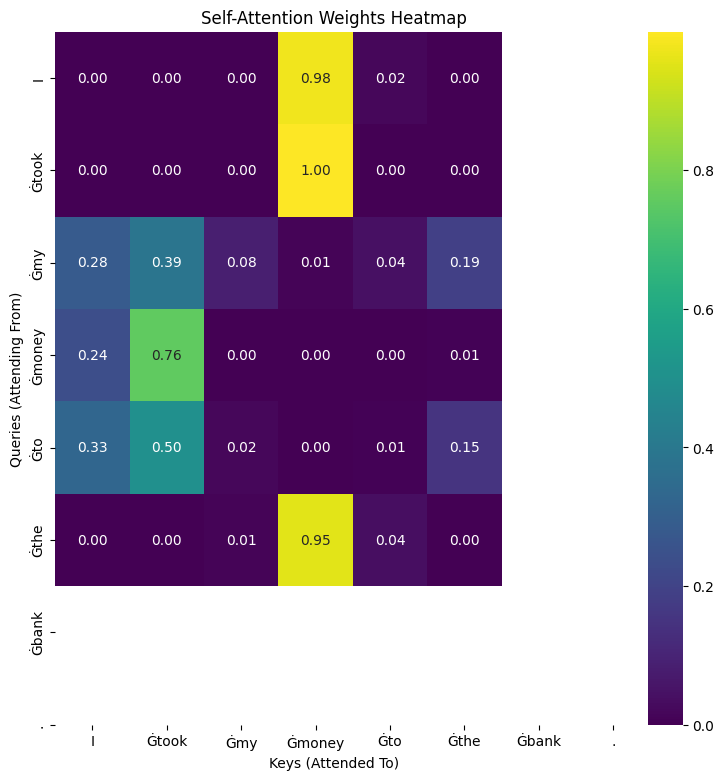

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'weights' is the attention weights tensor from the previous cell
# If not, you would need to recompute or access it.
# For this example, let's use the 'weights' variable defined in the previous cell.

plt.figure(figsize=(9, 9))
sns.heatmap(weights.detach().numpy(), annot=True, cmap='viridis', fmt=".2f",
            xticklabels=tokens, yticklabels=tokens) # Add token labels to axes

plt.title("Self-Attention Weights Heatmap")
plt.xlabel("Keys (Attended To)")
plt.ylabel("Queries (Attending From)")
plt.show()

Positional Encoding

In [ ]:
import numpy as np
import torch

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return torch.tensor(angle_rads, dtype=torch.float32)

pos_embed = positional_encoding(6, 16)
print("Positional Embeddings:\n", pos_embed)


Positional Embeddings:
 tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,
          0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  3.1098e-01,  9.5042e-01,  9.9833e-02,
          9.9500e-01,  3.1618e-02,  9.9950e-01,  9.9998e-03,  9.9995e-01,
          3.1623e-03,  9.9999e-01,  1.0000e-03,  1.0000e+00,  3.1623e-04,
          1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  5.9113e-01,  8.0658e-01,  1.9867e-01,
          9.8007e-01,  6.3203e-02,  9.9800e-01,  1.9999e-02,  9.9980e-01,
          6.3245e-03,  9.9998e-01,  2.0000e-03,  1.0000e+00,  6.3246e-04,
          1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  8.1265e-01,  5.8275e-01,  2.9552e-01,
          9.5534e-01,  9.4726e-02,  9.9550e-01,  2.9996e-02,  9.9955e-01,
          9.4867e-03,  9.9995e-01,  3.0000e-03,  1.0000e+00,  9.4868e-04,
          1.0000e+0

In [ ]:
import torch
import torch.nn as nn

# (seq_len, batch, embed_dim)
x = torch.rand(6, 1, 32)
encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=4)
out = encoder_layer(x)
print("Transformer Encoder Output Shape:", out.shape)

Transformer Encoder Output Shape: torch.Size([6, 1, 32])


In [ ]:

import torch
import torch.nn as nn

x = torch.rand(6, 1, 32)
mha = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=False)
out, attn = mha(x, x, x)
print("Multi-Head Output Shape:", out.shape)
print("Attention Weights Shape:", attn.shape)

Multi-Head Output Shape: torch.Size([6, 1, 32])
Attention Weights Shape: torch.Size([1, 6, 6])


In [ ]:

import torch
import torch.nn as nn

x = torch.rand(5, 2, 32)
mha = nn.MultiheadAttention(embed_dim=32, num_heads=4)
mask = torch.tensor([[False, False, False, True, True],
                     [False, False, False, False, True]]).bool()
out, attn = mha(x, x, x, key_padding_mask=mask)
print("Masked Attention Output:", out.shape)

Masked Attention Output: torch.Size([5, 2, 32])


In [ ]:
import torch
import torch.nn as nn

tgt = torch.rand(6, 1, 32)
memory = torch.rand(6, 1, 32)

decoder_layer = nn.TransformerDecoderLayer(d_model=32, nhead=4)
decoder = nn.TransformerDecoder(decoder_layer, num_layers=1)

tgt_mask = nn.Transformer.generate_square_subsequent_mask(6)
output = decoder(tgt, memory, tgt_mask=tgt_mask)
print("Decoder Output Shape:", output.shape)

Decoder Output Shape: torch.Size([6, 1, 32])


1. Tokenization with GPT-2

In [ ]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
text = "I took my money to the bank."
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text)

print("Tokens:", tokens)
print("Token IDs:", token_ids)

Tokens: ['I', 'Ġtook', 'Ġmy', 'Ġmoney', 'Ġto', 'Ġthe', 'Ġbank', '.']
Token IDs: [40, 1718, 616, 1637, 284, 262, 3331, 13]


Tokenization splits text into subword units GPT-2 understands

GPT-2 uses byte-level BPE (Byte Pair Encoding) tokenization

Output shows both the subword tokens and their numerical IDs

2. Model Processing and Attention

In [ ]:
from transformers import GPT2Tokenizer, GPT2Model
import torch

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2", output_attentions=True)

text = "I took my money to the bank."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

print("Token Embeddings Shape:", outputs.last_hidden_state.shape)
attention_weights = outputs.attentions[0]
mean_attention_weights = attention_weights.mean(dim=1).squeeze(0)
print("Mean Attention Weights Shape:", mean_attention_weights.shape)

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


Token Embeddings Shape: torch.Size([1, 8, 768])
Mean Attention Weights Shape: torch.Size([8, 8])


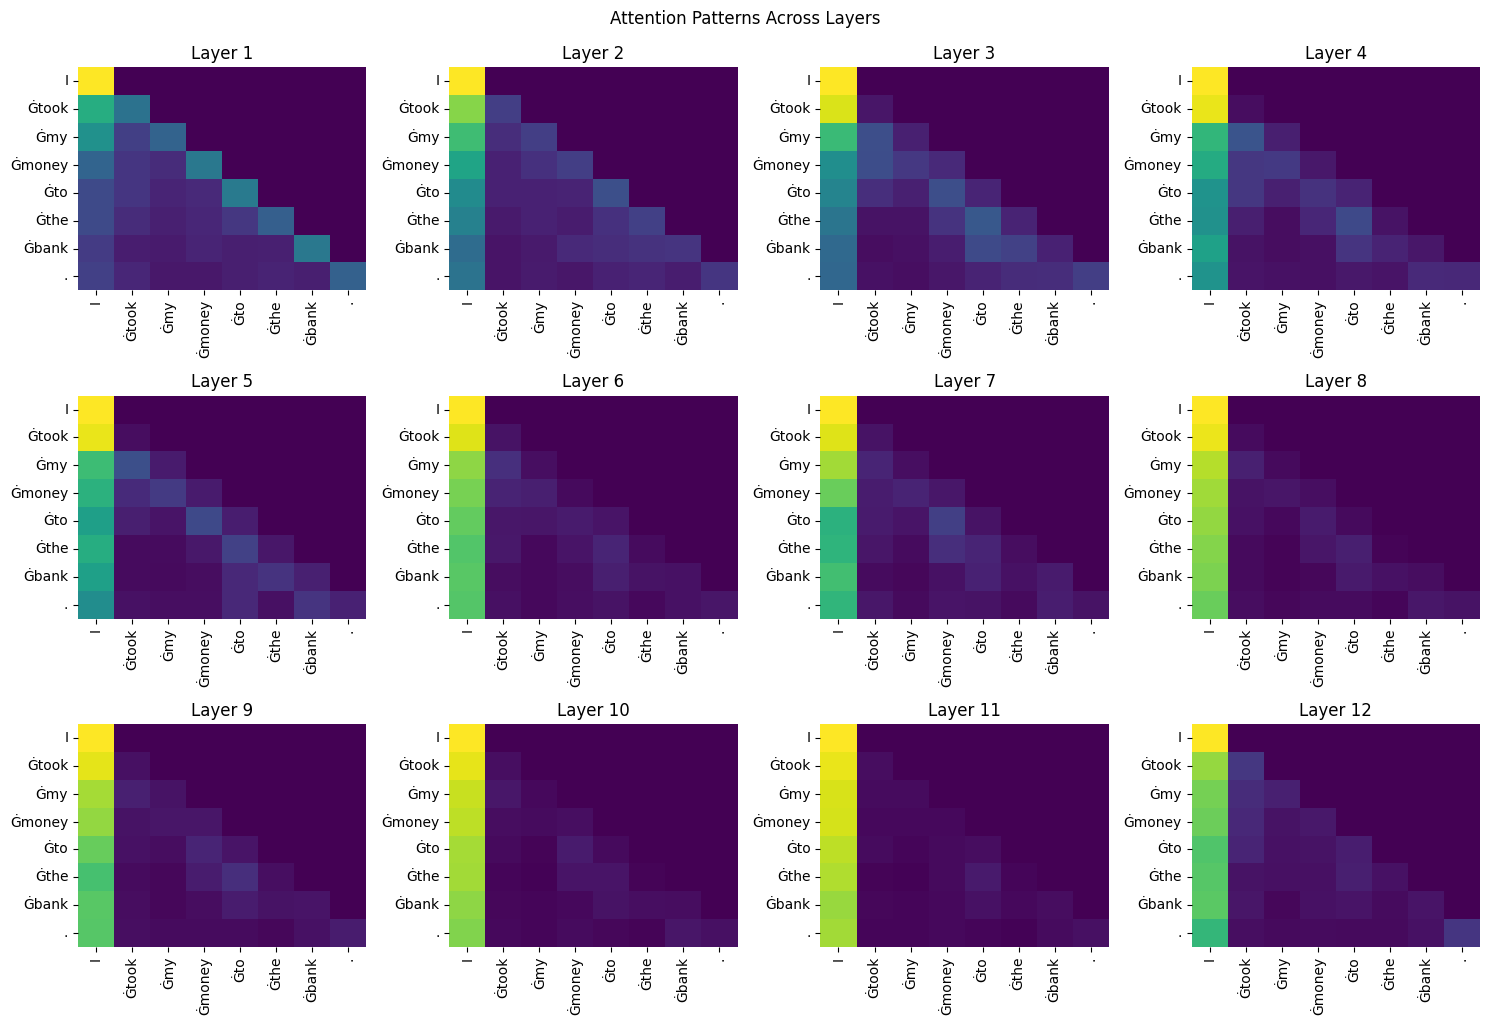

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Visualize attention weights for all layers
plt.figure(figsize=(15, 10))
for i, layer_attention in enumerate(outputs.attentions):
    plt.subplot(3, 4, i+1)
    head_avg = layer_attention.mean(dim=1).squeeze().detach().numpy()
    sns.heatmap(head_avg, xticklabels=tokens, yticklabels=tokens,
                cmap='viridis', cbar=False)
    plt.title(f"Layer {i+1}")
plt.tight_layout()
plt.suptitle("Attention Patterns Across Layers", y=1.02)
plt.show()

the patterns of attention are different across the various heatmaps. This is because each attention head learns to focus on different types of relationships in the data. Some heads might focus on syntactic relationships (like subject-verb), while others might focus on semantic relationships (like related words).

3. PCA Visualization of Embeddings

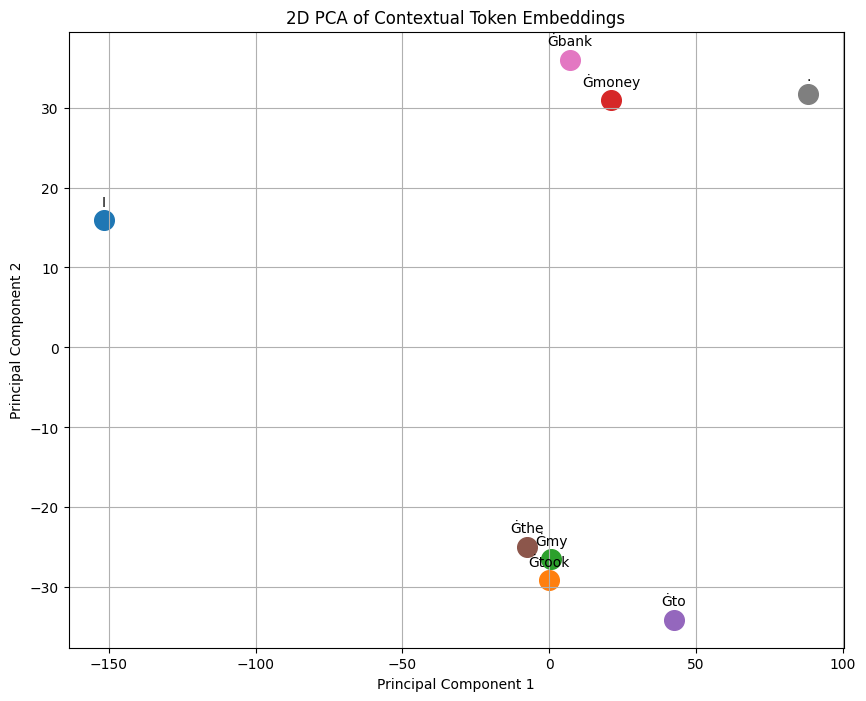

In [ ]:
from sklearn.decomposition import PCA

token_embeddings = outputs.last_hidden_state.squeeze(0).detach().numpy()
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(token_embeddings)

plt.figure(figsize=(10, 8))
for i, token in enumerate(tokens):
    plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1], s=200)
    plt.annotate(token, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]),
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.title("2D PCA of Contextual Token Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

PCA reduces 768-dim embeddings to 2D for visualization

Shows how the model positions tokens in semantic space

Similar-meaning words should be closer together

4. Self-Attention Mechanism

In [ ]:
import torch.nn.functional as F

# Simulated embeddings
x = torch.randn(6, 4)  # 6 tokens, 4 features
W_q = torch.randn(4, 2)
W_k = torch.randn(4, 2)
W_v = torch.randn(4, 2)

Q = x @ W_q
K = x @ W_k
V = x @ W_v

scores = Q @ K.T
scaled = scores / torch.sqrt(torch.tensor(K.shape[1]))
weights = F.softmax(scaled, dim=-1)
output = weights @ V

print("Self-Attention Output:\n", output)

Self-Attention Output:
 tensor([[-2.6731,  1.2044],
        [-0.0065,  0.2529],
        [ 0.2237,  0.2114],
        [ 0.1621,  0.3659],
        [-0.0221,  0.2798],
        [ 0.1865,  0.1549]])


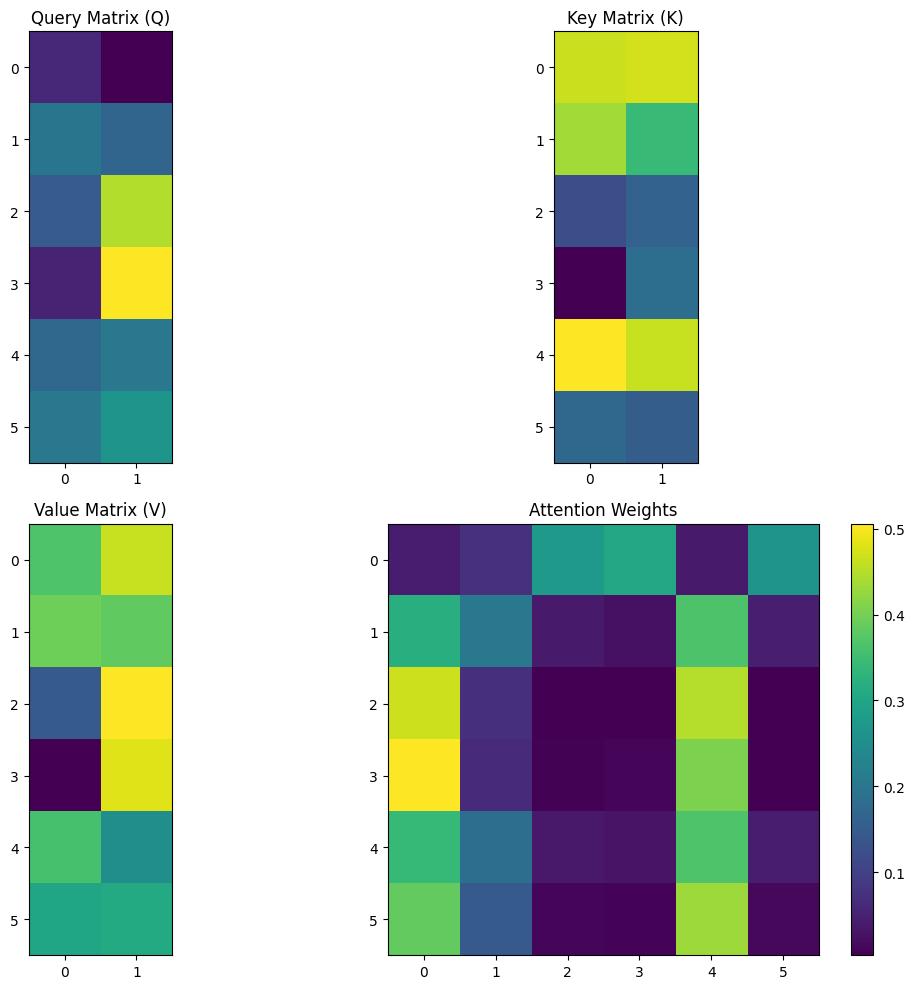

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Query-Key-Value matrices
axs[0,0].imshow(Q.detach().numpy(), cmap='viridis')
axs[0,0].set_title("Query Matrix (Q)")
axs[0,1].imshow(K.detach().numpy(), cmap='viridis')
axs[0,1].set_title("Key Matrix (K)")
axs[1,0].imshow(V.detach().numpy(), cmap='viridis')
axs[1,0].set_title("Value Matrix (V)")

# Attention weights
im = axs[1,1].imshow(weights.detach().numpy(), cmap='viridis')
axs[1,1].set_title("Attention Weights")
plt.colorbar(im, ax=axs[1,1])

plt.tight_layout()
plt.show()

5. Positional Encoding

In [ ]:
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return torch.tensor(angle_rads, dtype=torch.float32)

pos_embed = positional_encoding(6, 16)

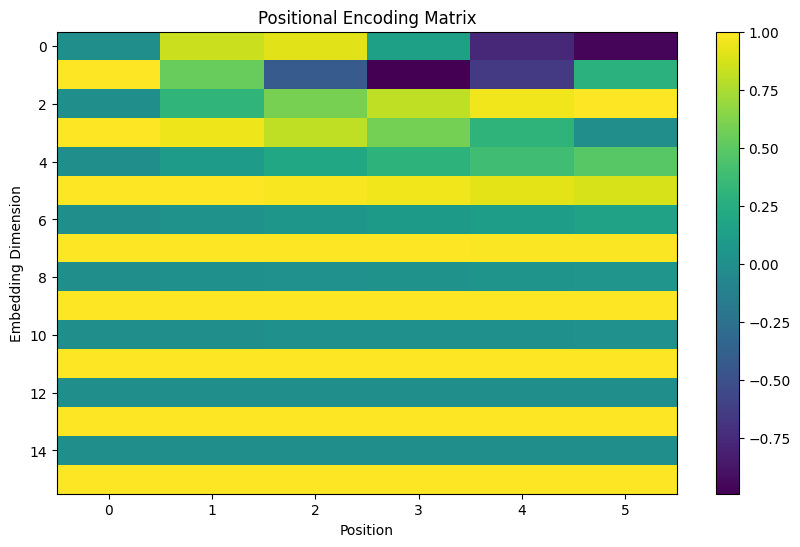

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(pos_embed.numpy().T, cmap='viridis', aspect='auto')
plt.title("Positional Encoding Matrix")
plt.xlabel("Position")
plt.ylabel("Embedding Dimension")
plt.colorbar()
plt.show()

6. Transformer Encoder Layer

In [ ]:
!pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import torch
import torch.nn as nn

x = torch.rand(6, 1, 32)
encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=4)
out = encoder_layer(x)

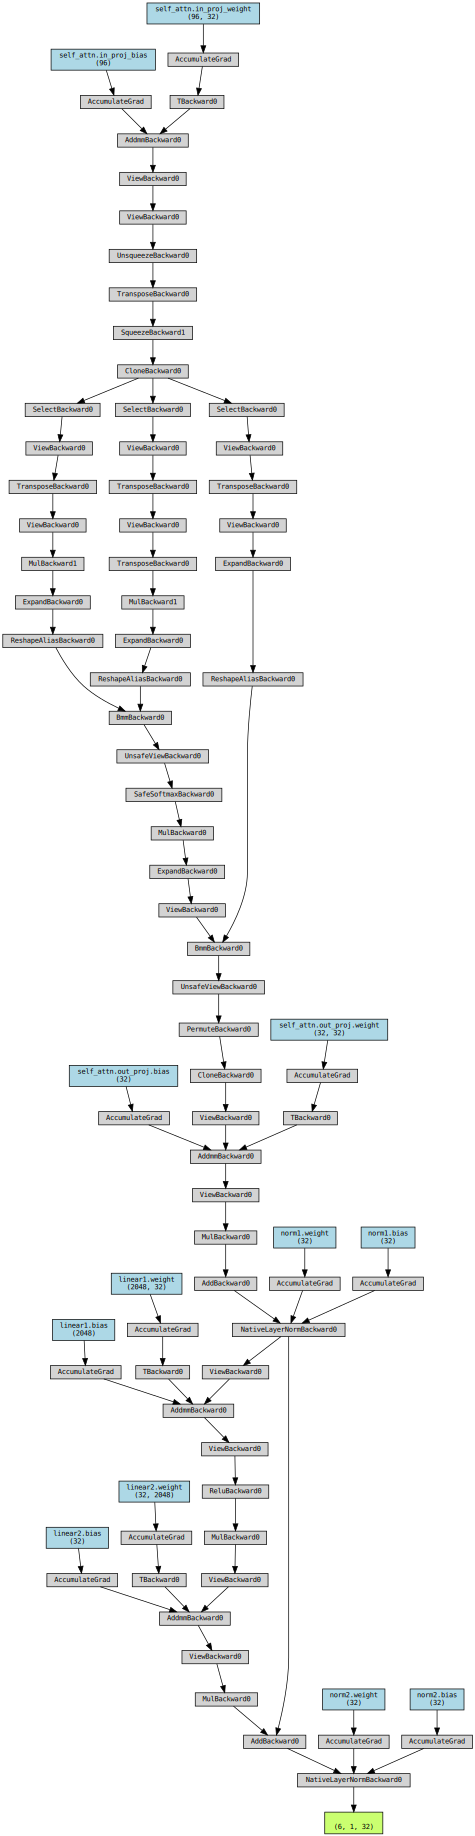

In [ ]:
# Visualize the architecture
from torchviz import make_dot

make_dot(out, params=dict(encoder_layer.named_parameters()))

7. Multi-Head Attention

In [ ]:
x = torch.rand(6, 1, 32)
mha = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=False)
out, attn = mha(x, x, x)
print(out,attn)

tensor([[[ 0.0836, -0.3221,  0.0511,  0.0738, -0.0533, -0.4502, -0.1790,
           0.1272,  0.0748, -0.0196,  0.2521, -0.2581, -0.3350, -0.0787,
           0.0060, -0.3787, -0.0485, -0.2444,  0.0985, -0.1246,  0.0250,
           0.1494,  0.0466, -0.0932, -0.2508, -0.0096,  0.1919,  0.0868,
           0.1666,  0.1148,  0.1205,  0.1887]],

        [[ 0.0836, -0.3205,  0.0500,  0.0715, -0.0472, -0.4486, -0.1793,
           0.1208,  0.0762, -0.0196,  0.2511, -0.2614, -0.3342, -0.0773,
           0.0119, -0.3776, -0.0456, -0.2454,  0.0958, -0.1268,  0.0187,
           0.1498,  0.0469, -0.0991, -0.2509, -0.0067,  0.1966,  0.0868,
           0.1665,  0.1079,  0.1132,  0.1927]],

        [[ 0.0839, -0.3190,  0.0471,  0.0739, -0.0485, -0.4500, -0.1773,
           0.1216,  0.0768, -0.0214,  0.2509, -0.2592, -0.3342, -0.0785,
           0.0090, -0.3788, -0.0493, -0.2443,  0.0960, -0.1258,  0.0197,
           0.1532,  0.0478, -0.0977, -0.2484, -0.0085,  0.1922,  0.0835,
           0.1655,  0.1121

8. Masked Attention

In [ ]:
x = torch.rand(5, 2, 32)
mask = torch.tensor([[False, False, False, True, True],
                     [False, False, False, False, True]]).bool()
out, attn = mha(x, x, x, key_padding_mask=mask)
print(out,attn)

tensor([[[-0.0831, -0.1148, -0.0912,  0.0757,  0.1036, -0.2284, -0.0770,
           0.1631,  0.0863, -0.0325,  0.1079, -0.2664, -0.2712,  0.0635,
           0.0097, -0.2619,  0.0368, -0.2432,  0.1175, -0.1730, -0.0043,
           0.1849,  0.0510, -0.1438, -0.1258, -0.1075,  0.0933,  0.1151,
           0.2265,  0.0702,  0.1004,  0.1791],
         [ 0.1227, -0.2543,  0.1514, -0.0271, -0.0569, -0.3727, -0.1530,
           0.0095,  0.0783, -0.0199,  0.2403, -0.1985, -0.4239, -0.1605,
           0.0299, -0.2390, -0.0911, -0.2492,  0.0688, -0.2971,  0.0562,
           0.0221,  0.0306, -0.0681, -0.2765, -0.0657,  0.2019, -0.0441,
           0.1941,  0.1104,  0.0892,  0.2158]],

        [[-0.0831, -0.1125, -0.0915,  0.0764,  0.1028, -0.2280, -0.0769,
           0.1631,  0.0848, -0.0321,  0.1053, -0.2665, -0.2708,  0.0639,
           0.0107, -0.2628,  0.0381, -0.2430,  0.1174, -0.1719, -0.0044,
           0.1855,  0.0523, -0.1438, -0.1231, -0.1062,  0.0939,  0.1154,
           0.2264,  0.0703, 

9. Transformer Decoder

In [ ]:
tgt = torch.rand(6, 1, 32)
memory = torch.rand(6, 1, 32)
decoder_layer = nn.TransformerDecoderLayer(d_model=32, nhead=4)
decoder = nn.TransformerDecoder(decoder_layer, num_layers=1)
tgt_mask = nn.Transformer.generate_square_subsequent_mask(6)
output = decoder(tgt, memory, tgt_mask=tgt_mask)
print(output)

tensor([[[-0.9077,  0.4356, -1.9075,  0.5866, -0.9955, -0.6651,  0.6315,
           0.0265,  1.1675, -0.3373,  0.9731,  1.1593,  1.1979, -0.8254,
           0.1690, -0.5606,  0.1517, -0.9069, -0.1256,  1.2542, -1.4714,
           0.7556, -1.2846, -0.8426,  0.1297,  1.3827,  1.8252, -0.2050,
          -1.5113,  0.5814, -1.2601,  1.3789]],

        [[-0.0896,  1.0637, -2.3069,  1.0205, -0.7076, -0.5772, -0.2724,
           2.3783,  0.4631, -0.6836, -0.0377,  0.5955, -1.1354, -0.2875,
          -1.1168, -0.9132,  1.0604,  1.1786, -0.4929,  1.8077,  0.1917,
          -0.0719, -0.6706,  0.8941,  1.1574, -1.1827, -0.1491, -0.8689,
           0.8824, -1.3216,  0.2782, -0.0860]],

        [[-0.9049,  0.5010, -0.9094, -1.0560,  0.3825,  0.0530,  2.7795,
           1.7181, -0.9739,  0.2970,  1.2323, -0.9652, -0.5527, -0.9377,
           0.2221, -0.1492,  0.8776,  1.3091, -1.9842,  0.4743, -0.2861,
          -0.6367,  0.1791,  0.3448,  0.0224, -0.9582,  0.2265, -1.8036,
           1.1720, -0.0050

Final Summary
Component	Purpose
Tokenization	- Split sentence into tokens
Embeddings -	Convert tokens to dense vectors
Positional Encoding	- Add word order information
Self-Attention -	Attend to other tokens in context
Multi-head Attention -	Learn different "views" or contexts
Encoder -	Build context-aware token representations
Decoder -	Generate target sequences (for translation or next-token prediction)
Masking	- Block attention to padding or future tokens

Understanding Masking in Transformers with "I took my money to the bank."

In [ ]:
import torch

# Suppose we have a batch of 2 sentences:
# 1. "I took my money to the bank." (6 real tokens + 1 padding)
# 2. "I deposited cash." (3 real tokens + 4 padding)
sentences = ["I took my money to the bank.", "I deposited cash"]

# After tokenization and padding to length 7:
token_ids = [
    [40, 6822, 616, 1938, 284, 262, 13],  # First sentence
    [40, 15684, 6035, 0, 0, 0, 0]          # Second sentence (padded)
]

# Create mask (False=real token, True=padding)
mask = torch.tensor([
    [False, False, False, False, False, False, False],  # First sentence (no padding)
    [False, False, False, True, True, True, True]       # Second sentence
])

In [ ]:
# Masked Language Modeling example
text = "I took my money to the [MASK]."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
print(outputs)

# Model tries to predict what [MASK] should be
# Likely top prediction: "bank"

BaseModelOutputWithPastAndCrossAttentions(last_hidden_state=tensor([[[-0.0796, -0.0654, -0.0842,  ..., -0.1442, -0.0456,  0.0142],
         [ 0.0539, -0.5238, -0.2598,  ...,  0.1299, -0.1450,  0.1692],
         [ 0.4521, -0.0359,  0.1594,  ..., -0.0694,  0.4240, -0.1537],
         ...,
         [-0.1504,  0.2280,  0.6045,  ..., -0.2033, -0.0936, -0.2230],
         [-0.7096, -0.4706, -0.0379,  ..., -0.2786, -0.1251, -0.2990],
         [ 0.0430, -0.3349, -0.0795,  ..., -0.0544, -0.4128, -0.0911]]],
       grad_fn=<ViewBackward0>), past_key_values=((tensor([[[[-1.5577,  2.0585,  1.3060,  ..., -1.3825, -0.6334,  1.2624],
          [-2.0697,  2.0200,  1.7544,  ..., -1.9600, -2.2305,  2.2838],
          [-1.8892,  2.4222,  2.5229,  ..., -1.4062, -1.9514,  1.7598],
          ...,
          [-3.0384,  1.3909,  1.3282,  ...,  0.5545, -0.9002,  1.5650],
          [-2.6104,  3.2568,  2.3357,  ..., -0.9136, -3.0185,  2.6700],
          [-1.7549,  2.0084,  2.3702,  ..., -1.3991, -1.6698,  1.3328]],